# ⚙️ Dataprocessing of datasets - counts
This notebook filters GTEx and TCGA expression data to include only **pancreas samples**, keeping gene identifiers and harmonizing formats for downstream CSD-analyzing.

**Goal:** Load, clean, normalize, transform and prepare RNA-seq data for multi-omics integration (CSD network analysis)

## Imports and files
Imports needed for all data processing:

In [1]:
import pandas as pd 
import numpy as np
import os
from pathlib import Path
import gzip
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.pylab import normal
from functools import reduce
from random import sample
import re


In [2]:
# Directory paths
DATA_DIR = Path("../../../data/raw/")
OUT_DIR = Path("../../../data/processed/")
RESULT_DIR = Path("../../../results/")

# Raw data
gtex_gct = DATA_DIR / "gtex/GTEx_Analysis_2025-08-22_v11_RNASeQCv2.4.3_gene_reads.gct"
gtex_meta = DATA_DIR / "gtex/GTEx_Analysis_v11_Annotations_SampleAttributesDS.txt"
tcga_samples = DATA_DIR / "gdc_sample_sheet.tsv"
tcga_counts_dir = DATA_DIR / "tcga/"


# Processed data output paths
gtex_output_path = OUT_DIR / "gtex/gtex_pancreas_processed.csv"
tcga_output_path = OUT_DIR / "tcga/tcga_pancreas_processed.csv"

# Paths for data integration
gtf_path = DATA_DIR / "gencode/gencode.v47.genes.gtf"
gtex_out_int = OUT_DIR / "gtex/gtex_int.csv"
tcga_out_int = OUT_DIR / "tcga/tcga_int.csv"
mapping_file = OUT_DIR / "genelist/common_protein_coding_genes.txt"
proteome_common_genes = OUT_DIR / "genelist/proteome_common_genes.txt"


# Paths for final file
out_gtex_final = OUT_DIR / "rna_healthy.txt"
out_tcga_final = OUT_DIR / "rna_cancer.txt"

## Helper functions

### Load functions:


In [3]:
def load_gtex(gtex_meta, gtex_gct):

    # 1. Load metadata to find pancreas sample
    meta = pd.read_csv(gtex_meta, sep="\t")
    pancreas_ids = meta.loc[meta["SMTS"] == "Pancreas", "SAMPID"].tolist()
    if not pancreas_ids:
        raise ValueError('Ingen pancreas-samples funnet i GTEx metadata.')
    print(f"Found {len(pancreas_ids)} pancreas samples in GTEx metadata.")

    # 2. Read GTEx expression data (skipping first two rows) (only header)
    header = pd.read_csv(gtex_gct, sep="\t", skiprows=2, nrows = 0)
    header.columns = header.columns.str.strip()

    all_cols = header.columns.tolist()

    # 3. Identify the gene_id column 
    gene_col = "Name" if "Name" in all_cols else all_cols[0]

    # 4. select only gene_id + pancreas samples
    keep_cols = [gene_col] + [c for c in all_cols if c in pancreas_ids]
    print(f"Loading only {len(keep_cols)-1} pancreas column")

    # 5. Load only selected columns
    expr = pd.read_csv(gtex_gct, sep = "\t", skiprows=2, usecols=keep_cols)
    print(f"Loaded GTEx subset with shape: {expr.shape}")

    expr = expr.rename(columns={gene_col: "gene_id"})

    return expr


def load_tcga_tpm(filepath, value_col="tpm_unstranded"):
    """
    Load a TCGA STAR gene counts file into a pandas Series.
    Default: tpm_unstranded.
    """
    df = pd.read_csv(filepath, sep="\t", comment="#", header=0)

    # Drop QC rows (N_unmapped, N_multimapping, etc.)
    first_col = df.columns[0]
    df = df[~df[first_col].astype(str).str.startswith(("N_", "__"))]
    

    # Use first column (gene_id) as index
    df = df[[first_col, value_col]]

    df = df.rename(columns={first_col: "gene_id"})

    return df


def process_tcga_data(counts_dir, sample_sheet, value_col="tpm_unstranded"):
    
    all_samples = []
    input_dir = Path(counts_dir)

    # Load sample sheet and build mapping: File Name -> Sample ID
    sample_meta = pd.read_csv(sample_sheet, sep="\t")
    sample_meta.columns = sample_meta.columns.str.strip()
    file_to_sample = dict(
        zip(
            sample_meta["File Name"].astype(str).str.strip(),
            sample_meta["Sample ID"].astype(str).str.strip()
        )
    )
    print(f"Loaded {len(file_to_sample)} sample mappings from {Path(sample_sheet).name}")


    # Loop through all .tsv files containing STAR counts
    for fpath in input_dir.rglob("*.tsv"):
        if "star_gene_counts" in fpath.name:
            sample_id = file_to_sample.get(fpath.name)
            if sample_id is None:
                print(f"WARNING: '{fpath.name}' not found in sample sheet. Using UUID fallback.")
                sample_id = fpath.name.split(".")[0]
            df = load_tcga_tpm(fpath, value_col=value_col)
            df = df.rename(columns={value_col: sample_id})

            all_samples.append(df)    

    if not all_samples:
        raise ValueError(f"No STAR counts files found in {input_dir}.")
    print(f"Found {len(all_samples)} STAR counts files in {input_dir}.")
    # Merge all samples on gene_id
    tcga = reduce(lambda left, right: pd.merge(left, right, on="gene_id", how="outer"), all_samples)
    print(f"Merged {len(all_samples)} samples into a single DataFrame with shape: {tcga.shape}")
        
    return tcga

    

### Reuseble functions

In [ ]:
# Clean processed datasets

def clean_df(df):

    # Ensure 'gene_id' column exists
    if 'gene_id' not in df.columns:
        raise ValueError("Input DataFrame must contain 'gene_id' column.")

    print(f"Original data shape: {df.shape}")
    
    # Remove version numbers from gene IDs
    df['gene_id'] = df['gene_id'].astype(str).str.split('.').str[0]

    # Remove duplicates
    before = df.shape[0]
    df = df.drop_duplicates(subset='gene_id', keep= 'first')
    removed = before - df.shape[0]
    print(f"Removed {removed} duplicate genes.")
    print(f"Data shape after removing duplicates: {df.shape}")

    # Sort by gene_id
    df_sort = df.sort_values('gene_id').reset_index(drop=True)

    return df_sort

def load_protein_coding_genes(gtf_path, out_file=None):
    
    gene_ids = set()
    records = []

    # Precompile regex patterns for efficiency
    gene_id_pattern = re.compile(r'gene_id "([^"]+)"')
    gene_name_pattern = re.compile(r'gene_name "([^"]+)"')
    biotype_pattern = re.compile(r'gene_type "([^"]+)"|gene_biotype "([^"]+)"')

    # Open file (gzipped or plain text)
    if str(gtf_path).endswith('.gz'):
        file_handle = gzip.open(gtf_path, 'rt')
    else:
        file_handle = open(gtf_path, 'r')

    with file_handle as file:
        for line in file:

            if line.startswith('#'):
                continue

            fields = line.strip().split('\t')

            if fields[2] != 'gene':
                continue

            info = fields[8]

            # extract biotype
            biotype_match = biotype_pattern.search(info)
            if not biotype_match:
                continue
            if biotype_match.group(1) != "protein_coding":
                continue
            
            # extract gene_id
            gene_id_match = gene_id_pattern.search(info)
            if not gene_id_match:
                continue
            gene_id = gene_id_match.group(1).split(".")[0]

            # extract gene_name
            gene_name_match = gene_name_pattern.search(info)
            gene_name = gene_name_match.group(1) if gene_name_match else None

            gene_ids.add(gene_id)
            records.append((gene_id, gene_name))
                

    df = pd.DataFrame(records, columns=["gene_id", "gene_name"]).drop_duplicates()

    print(f"Extracted {len(gene_ids)} protein-coding genes from {Path(gtf_path)}")

    if out_file:
        df.to_csv(out_file, index=False)
        print(f"Saved gene ID to name mapping to {out_file}")

    return gene_ids, df

def filter_protein_coding(df, pc_genes, id_col='gene_id'):
    """
    Filter a DataFrame to only protein-coding genes.
    pc_genes should be a Python set of gene IDs (e.g., from load_protein_coding_genes(...)[0]).
    Returns a DataFrame sorted by id_col with index reset.
    """
    if id_col not in df.columns:
        raise ValueError(f"Input DataFrame must contain '{id_col}' column.")
    # pc_genes is a set, so use .isin(pc_genes) directly
    df_filt = df[df[id_col].astype(str).isin(pc_genes)].copy()
    df_filt = df_filt.sort_values(by=id_col).reset_index(drop=True)
    print(f"Filtered to protein-coding genes: {df_filt.shape}")
    return df_filt

def filter_low_expression_counts(counts_df, min_cpm=1, min_fraction=0.2):
    """""
    Filter lowly expressed genes using CPM threshold
    """
    
    gene_ids = counts_df["gene_id"]
    expr = counts_df.drop(columns=["gene_id"])

    # Calculate library sizes
    lib_size = expr.sum(axis=0)

    # CPM calculation
    cpm = expr.div(lib_size, axis=1)* 1e6

    # Minimum number of samples required
    min_samples = int(np.ceil(min_fraction * cpm.shape[1]))

    keep_mask = (cpm > min_cpm).sum(axis=1) >= min_samples

    filtered_df = counts_df.loc[keep_mask].reset_index(drop=True)

    print(f"Original genes: {counts_df.shape[0]}")
    print(f"Genes retained: {filtered_df.shape}")
    print(f"Minimum samples required: {min_samples}")

    return filtered_df

def harmonize_datasets(gtex_df, tcga_df, proteome_genes):

    id_col = "gene_id"

    # If user provided a path, load it
    if isinstance(proteome_genes, (str, Path)):
        proteome_genes = pd.read_csv(proteome_genes, header=None)[0].tolist()

    # Find common genes
    common_genes = (set(gtex_df[id_col]) &
                    set(tcga_df[id_col]) &
                    set(proteome_genes)
                    )
    
    print(f"Number of common protein-coding genes: {len(common_genes)}")
        
    #Filter both datasets
    gtex_filt = gtex_df[gtex_df[id_col].isin(common_genes)]
    tcga_filt = tcga_df[tcga_df[id_col].isin(common_genes)]

    with open(OUT_DIR /"genelist/common_genes.txt", "w") as f:
        for gene in common_genes:
            f.write(str(gene) + "\n")

    # Sort both datasets by gene_id to ensure same order
    gtex_filt = gtex_filt.sort_values(by=id_col).reset_index(drop=True)
    tcga_filt = tcga_filt.sort_values(by=id_col).reset_index(drop=True)

    print(f"Shapes after filtering to common genes - GTEx: {gtex_filt.shape}, TCGA: {tcga_filt.shape}")

    return gtex_filt, tcga_filt


# PCA plot before and after three dataframes

def plot_pca(df_gtex, df_tcga, title, ax=None):

    # Expect genes as rows, samples as columns; require Axes object
    if ax is None:
        raise ValueError('An Axes object must be provided (use subplots).')

    # Drop gene_id column if present (we only want numeric sample columns)
    if 'gene_id' in df_gtex.columns:
        df_gtex = df_gtex.drop(columns=['gene_id'])
    if 'gene_id' in df_tcga.columns:
        df_tcga = df_tcga.drop(columns=['gene_id'])

    # Sanity checks
    if df_gtex.empty or df_tcga.empty:
        raise ValueError('One of the input DataFrames is empty after preprocessing.')

    # Combine datasets along genes then transpose (samples as rows)
    combined_df = pd.concat([df_gtex, df_tcga], axis=1)
    combined_df = combined_df.T
    combined_df = combined_df.fillna(0)

    # Standardize features (genes)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(combined_df)

    # PCA to 2 components
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(scaled_data)

    # Build labels: number of columns == number of samples per dataset
    labels = (['GTEx'] * df_gtex.shape[1]) + (['TCGA'] * df_tcga.shape[1])

    # Calculate percentage of variance explained
    variance_ratio = pca.explained_variance_ratio_
    pc1_var = variance_ratio[0] * 100
    pc2_var = variance_ratio[1] * 100

    print(variance_ratio)

    # Plot each dataset separately (indent scatter inside loop)
    for lab in sorted(set(labels)):
        mask = [l == lab for l in labels]
        ax.scatter(pcs[mask, 0], pcs[mask, 1], label=lab, alpha=0.7, s=20)

    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pc1_var:.2f}%)')
    ax.set_ylabel(f'PC2 ({pc2_var:.2f}%)')
    ax.grid(True, alpha=0.3)
    ax.legend()

## Main pipeline

### Load and clean data



From raw data to clean .csv datasets:

GTEX raw tpm -> GTEX only pancreas genes -> 

In [5]:
# Process GTEx data
gtex_raw = load_gtex(gtex_meta, gtex_gct)


C:\Users\tiril\AppData\Local\Temp\ipykernel_9964\208867496.py:4: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(gtex_meta, sep="\t")


Found 961 pancreas samples in GTEx metadata.
Loading only 384 pancreas column
Loaded GTEx subset with shape: (74628, 385)


In [6]:
# Process TCGA data
tcga_raw = process_tcga_data(tcga_counts_dir, tcga_samples, value_col="unstranded")


Loaded 183 sample mappings from gdc_sample_sheet.tsv
Found 183 STAR counts files in ..\..\..\data\raw\tcga.
Merged 183 samples into a single DataFrame with shape: (60660, 184)


In [7]:
# Clean datasets
gtex_clean = clean_df(gtex_raw)
tcga_clean = clean_df(tcga_raw)

Original data shape: (74628, 385)
Removed 0 duplicate genes.
Data shape after removing duplicates: (74628, 385)
Original data shape: (60660, 184)
Removed 44 duplicate genes.
Data shape after removing duplicates: (60616, 184)


### Data integration

In [8]:
# Filter out PC genes
pc_genes = load_protein_coding_genes(gtf_path, out_file=mapping_file)[0]
gtex_pc_filt= filter_protein_coding(gtex_clean, pc_genes)
tcga_pc_filt = filter_protein_coding(tcga_clean, pc_genes)



Extracted 19355 protein-coding genes from ..\..\..\data\raw\gencode\gencode.v47.genes.gtf
Saved gene ID to name mapping to ..\..\..\data\processed\genelist\common_protein_coding_genes.txt
Filtered to protein-coding genes: (19355, 385)
Filtered to protein-coding genes: (19299, 184)


In [9]:
gtex_filt = filter_low_expression_counts(gtex_pc_filt, min_cpm=1, min_fraction=0.2)
tcga_filt = filter_low_expression_counts(tcga_pc_filt, min_cpm=1, min_fraction=0.2)


Original genes: 19355
Genes retained: (13833, 385)
Minimum samples required: 77
Original genes: 19299
Genes retained: (14993, 184)
Minimum samples required: 37


In [10]:
# Harmonize genelist
gtex_harm, tcga_harm = harmonize_datasets(gtex_filt, tcga_filt, proteome_common_genes)

gtex_harm.to_csv("../../../data/processed/gtex/gtex_counts_harm.csv", index=False)
tcga_harm.to_csv("../../../data/processed/tcga/tcga_counts_harm.csv", index=False)


Number of common protein-coding genes: 7964
Shapes after filtering to common genes - GTEx: (7964, 385), TCGA: (7964, 184)


### Data Transformation: 

#### DeSeq2 transformasjon

In [11]:
gtex_deseq = pd.read_csv("../../../data/processed/gtex/gtex_vst.csv", index_col=0)
tcga_deseq = pd.read_csv("../../../data/processed/tcga/tcga_vst.csv", index_col=0)

gtex_deseq = gtex_deseq.reset_index().rename(columns={"index": "gene_id"})

tcga_deseq = tcga_deseq.reset_index().rename(columns={"index": "gene_id"})

print(gtex_deseq.shape)
print(tcga_deseq.shape)



(7964, 385)
(7964, 184)


## Resulting pca plot

[0.45683151 0.15343638]
[0.42499396 0.07844171]


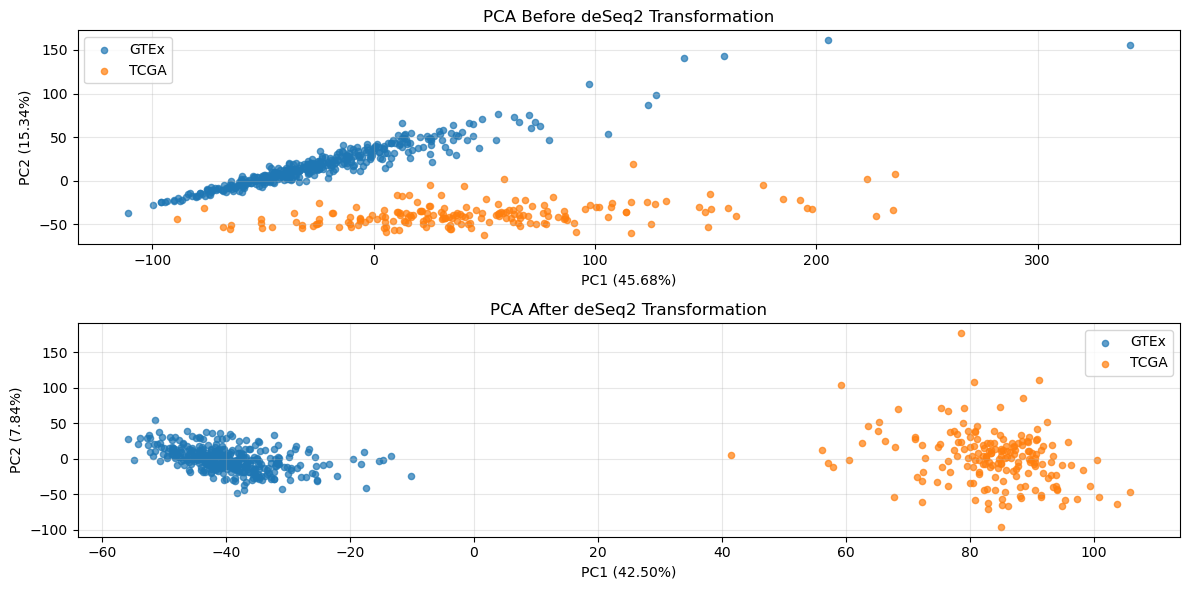

In [15]:

fig, axes = plt.subplots(2, figsize =(12, 6))

plot_pca(gtex_harm.drop(columns=['gene_id']), tcga_harm.drop(columns=['gene_id']),
         title="PCA Before deSeq2 Transformation", ax=axes[0])
plot_pca(gtex_deseq.drop(columns=['gene_id']), tcga_deseq.drop(columns=['gene_id']),
         title="PCA After deSeq2 Transformation", ax=axes[1])
         
plt.tight_layout()

## Save section

In [12]:
# Save loaded and processed data
gtex_raw.to_csv(gtex_output_path, index=False)
print(f"Processed GTEx pancreas data saved to {gtex_output_path}")
tcga_raw.to_csv(tcga_output_path, index=False)
print(f"Processed TCGA data saved to {tcga_output_path}")

# Save final dataset with gene_id and original sample IDs as header
gtex_deseq.to_csv(out_gtex_final, header=True, index=False)
print(f"Final dataset for GTEX is saved to {out_gtex_final}")
tcga_deseq.to_csv(out_tcga_final, header=True, index=False)
print(f"Final dataset for TCGA is saved to {out_tcga_final}")

Processed GTEx pancreas data saved to ..\..\..\data\processed\gtex\gtex_pancreas_processed.csv
Processed TCGA data saved to ..\..\..\data\processed\tcga\tcga_pancreas_processed.csv
Final dataset for GTEX is saved to ..\..\..\data\processed\rna_healthy.txt
Final dataset for TCGA is saved to ..\..\..\data\processed\rna_cancer.txt


In [ ]:
# Converts gene expression files to c++ findcorrvar-compatible format
def prepare_findcorrvar_input(
    df_path: str | os.PathLike,
    out: str = OUT_DIR / "ExpData_rna_Healthy.txt",
    float_format: str = "{:.6f}",
):
    df = pd.read_csv(df_path)

    if "gene_id" not in df.columns:
        first_col = df.columns[0]
        df = df.rename(columns={first_col: "gene_id"})

    genes = df["gene_id"].astype(str).values
    values = df.drop(columns=["gene_id"]).apply(pd.to_numeric, errors="coerce")

    with open(out, "w") as f:
        for gene, row in zip(genes, values.to_numpy()):
            formatted_values = " ".join(float_format.format(v) for v in row)
            f.write(f"{gene} {formatted_values}\n")

prepare_findcorrvar_input(out_gtex_final, out=OUT_DIR / "ExpData_rna_Healthy.txt", float_format="{:.6f}")
prepare_findcorrvar_input(out_tcga_final, out=OUT_DIR / "ExpData_rna_Cancer.txt", float_format="{:.6f}")